In [1]:
%cd ..

/home/dev/workspace


# Iterative inference on single batches

Probes the `IterativeGuide` + `AutoMeanFieldProposal` inference algorithm from
the `poisson_captcha` experiment on one batch at a time, without running the
full trainer: how far the inner `optimistix` solve moves the guide, what it
costs, and what the adapted posterior looks like.

The model is the marked-Poisson-process formulation: a total firing mass
``z_rate ~ Gamma`` allocated over anchors by ``z_where ~ Dirichlet`` (their
product is the intensity field), and glyph identity chosen by the per-anchor
mark simplex ``z_mark ~ Dirichlet``.

Knobs live in the `overrides` list below. Everything here runs **eagerly** (no
jit), so it is usable locally at small settings; on the pod, raise
`data.batch_size`, `guide.max_steps`, and the particle counts.

In [2]:
import functools
import os
import time

import hydra
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from numpyro.handlers import block, seed, substitute, trace
from omegaconf import OmegaConf
import optimistix
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

PosixPath('/home/dev/workspace')

In [3]:
overrides = [
    "ckpt_path=/mnt/obelisk-shared/eli/captcha-numpyro/logs/train/runs/2026-07-21_23-57-07/saved/checkpoint-epoch10.npy",
    "+experiment=poisson_captcha",
    "data.batch_size=4",              # pod: 32
    "guide.max_steps=2",            # inner-solve budget; pod: 100+
    "guide.tracer.beta=0.05",
    "guide.tracer.num_particles=4",   # pod: 4
    "learner.tracer.num_particles=4", # pod: 4
    "+model.scale=0.1",
]

with hydra.initialize_config_dir(version_base="1.3",
                                 config_dir=os.getcwd() + "/configs"):
    cfg = hydra.compose(config_name="train", overrides=overrides)

datamodule = hydra.utils.instantiate(cfg.data)
model = hydra.utils.instantiate(cfg.model)
guide = hydra.utils.instantiate(cfg.guide)
learner = hydra.utils.instantiate(cfg.learner, data_shape=datamodule.shape,
                                  guide=guide, model=model)
learner.setup_step(datamodule)
guide = learner.guide

E0723 20:56:01.907728  114686 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [4]:
# Optional: load model parameters from a training checkpoint instead of a
# fresh initialization.
# from src.utils import unserialize_key
# checkpoint = np.load("logs/train/runs/<run>/saved/checkpoint-epoch<N>.npy",
#                      allow_pickle=True).item()
# learner.load(jax.tree.map_with_path(unserialize_key, checkpoint))

In [5]:
# Record every inner solve's Solution so we can read off step counts and
# convergence results. (Eager-only instrumentation -- do not jit around this.)
solutions = []
if not getattr(optimistix.minimise, "_is_spy", False):
    _orig_minimise = optimistix.minimise
    def _spy(*args, **kwargs):
        solution = _orig_minimise(*args, **kwargs)
        solutions.append(solution)
        return solution
    _spy._is_spy = True
    optimistix.minimise = _spy

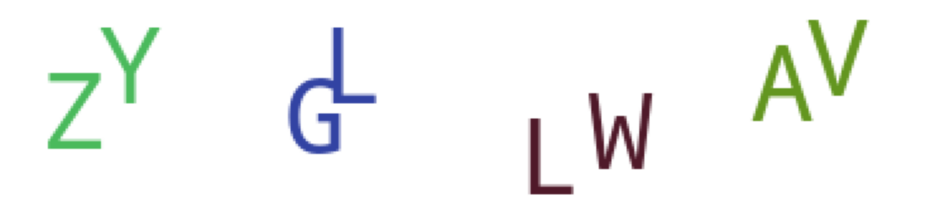

In [6]:
data = next(iter(datamodule.valid_dataloader()))[0]

fig, axes = plt.subplots(1, data.shape[0], figsize=(3 * data.shape[0], 3))
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(data[i])
    ax.set_axis_off()

## One adaptation, timed

Run the inner solve once on this batch and see how many steps it takes, whether
it hits the budget or the tolerance, and how far each variational parameter
moves from its prior-mirror initialization.

In [7]:
t0 = time.time()
with seed(rng_seed=0), substitute(data=learner.parameters):
    adapted = jax.block_until_ready(guide.adapt(data))
wall = time.time() - t0

solution = solutions[-1]
print(f"{int(solution.stats['num_steps'])} inner steps "
      f"(result: {solution.result}) in {wall:.1f}s")

2 inner steps (result: optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>) in 216.3s


In [8]:
with seed(rng_seed=0):
    with block(hide_fn=lambda msg: msg["type"] == "param"):
        init_trace = trace(guide.guide).get_trace(data)
init = {name: site["value"] for name, site in init_trace.items()
        if site["type"] == "param"}

for name, value in adapted.items():
    delta = np.abs(np.asarray(value) - np.asarray(init[name]))
    print(f"{name}: shape {value.shape} max|d| {delta.max():.4g} "
          f"mean|d| {delta.mean():.4g}")

color_auto_concentration0: shape (4, 3) max|d| 0 mean|d| 0
color_auto_concentration1: shape (4, 3) max|d| 0 mean|d| 0
z_mark_auto_concentration: shape (4, 43, 55, 36) max|d| 4.201 mean|d| 0.005635
z_rate_auto_concentration: shape (4,) max|d| 0 mean|d| 0
z_rate_auto_rate: shape (4,) max|d| 0 mean|d| 0
z_where_auto_concentration: shape (4, 2365) max|d| 7.19 mean|d| 0.1451


## Does adaptation help the outer objective?

Score the full outer ELBO (via the learner's `AdaptiveElboTracer`) with the
same noise, once with the fresh prior-mirror guide and once with per-batch
adaptation. `functools.partial(guide, adaptation=None)` hides the `adapt`
method, so the tracer skips adaptation for the baseline.

In [9]:
def outer_metrics(g, key=1):
    loss, state = learner.tracer.loss(random.key(key), learner.parameters, {},
                                      learner.model, g, data)
    metrics, _ = learner._step_telemetry(loss, state)
    return {k: float(v) for k, v in metrics.items()
            if k in ("loss", "nll", "kl", "ess", "log_w")}

fresh = outer_metrics(functools.partial(guide, adaptation=None))
adapted_metrics = outer_metrics(guide)
print(f"{'':>10} {'fresh':>14} {'adapted':>14}")
for k in fresh:
    print(f"{k:>10} {fresh[k]:>14.4g} {adapted_metrics[k]:>14.4g}")

                    fresh        adapted
      loss     -7.555e+04     -7.773e+04
     log_w      7.555e+04      7.773e+04
       nll     -1.889e+04      -1.98e+04
        kl              0          371.1
       ess           0.25           0.25


## Reconstructions, intensity maps, and a template-matching oracle

Left to right: data, posterior-mean reconstruction, the adapted firing
intensity field ``lambda = z_rate * z_where`` (particle-averaged, on the
anchor grid), and where the intensity *ought* to concentrate by pure template
matching -- each glyph's support mask correlated with the image's ink (the
correlation is the adjoint of the model's ``conv_transpose`` render, so it
lives on exactly the same anchor grid), normalized per glyph and maxed over
the dictionary.

/home/dev/workspace/src/inference/tracer.py:371: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


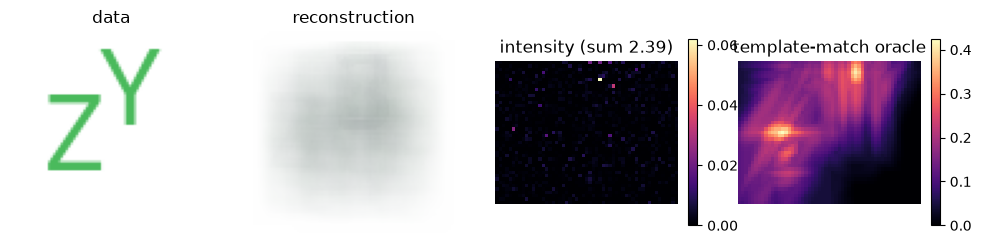

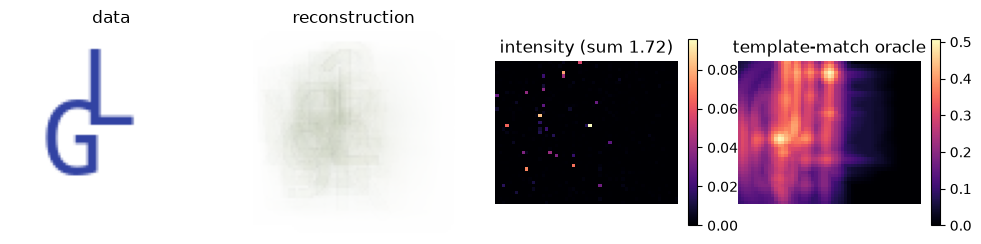

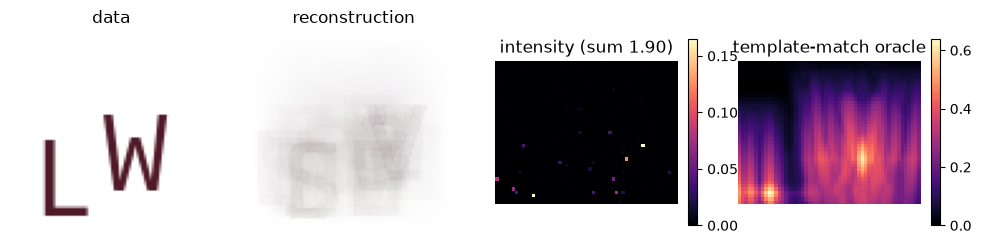

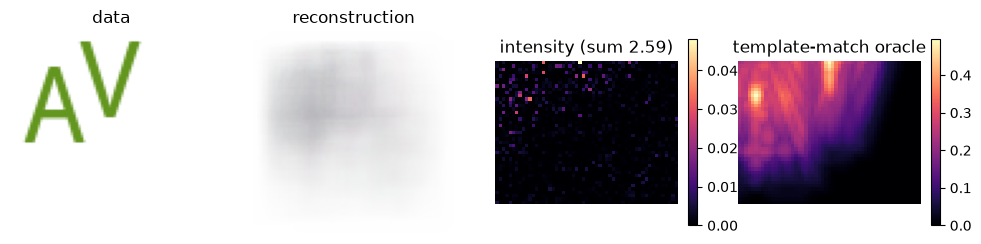

In [10]:
from src.model.model import _dictionary_support_masks

placements = model.keywords["placements"]
grid = (placements.height, placements.width)
masks = _dictionary_support_masks(placements.shape_dict.shapes)  # (K, kh, kw, 1)
ink = 1. - jnp.asarray(data).mean(axis=-1, keepdims=True)        # (B, H, W, 1)

def correlate_one(mask):
    kernel = (mask / mask.sum())[..., jnp.newaxis]               # (kh, kw, 1, 1)
    return jax.lax.conv_general_dilated(
        ink, kernel, window_strides=(placements.stride,) * 2, padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )[..., 0]                                                    # (B, out_h, out_w)

# Mean ink under each glyph's support at every anchor, maxed over glyphs.
oracle = jax.vmap(correlate_one)(masks).max(axis=0)

samples, predictions = learner(data, stage="valid")
recon = predictions["obs"]["ev"].mean(axis=0)
z_rate = predictions["z_rate"]["value"]                          # (P, B)
z_where = predictions["z_where"]["value"]                        # (P, B, HW)
intensity = (z_rate[..., jnp.newaxis] * z_where).mean(axis=0)
intensity = np.asarray(intensity).reshape(data.shape[0], *grid)
for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    axes[0].imshow(data[i])
    axes[0].set_title("data")
    axes[1].imshow(np.clip(recon[i], 0., 1.))
    axes[1].set_title("reconstruction")
    im = axes[2].imshow(intensity[i], cmap="magma")
    axes[2].set_title(f"intensity (sum {intensity[i].sum():.2f})")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    im = axes[3].imshow(oracle[i], cmap="magma")
    axes[3].set_title("template-match oracle")
    fig.colorbar(im, ax=axes[3], fraction=0.046)
    for ax in axes:
        ax.set_axis_off()

## Allocation and mark diagnostics

Where does the inner objective want the firing mass to move, and has the mark
simplex committed to a glyph where the intensity concentrates?

- The gradient of the inner (reconstruction) objective with respect to the
  *unconstrained* ``z_where`` concentrations shows which anchors are being
  pulled -- compare it against the oracle to see whether the pull points at
  the right anchors.
- ``E[z_rate]`` under the adapted guide is the posterior expected glyph count;
  the prior mean is ``expected_count``.
- The per-anchor mark simplex ``z_mark`` should have low entropy at the
  intensity peak (a committed glyph choice) even if it stays vague elsewhere.

posterior E[z_rate] per image: [2. 2. 2. 2.] (prior mean 2.0)
image 0: peak anchor (np.int64(5), np.int64(31)) glyph 3 (p=0.12, entropy 3.29 of max 3.58)
image 1: peak anchor (np.int64(19), np.int64(28)) glyph 21 (p=0.28, entropy 2.66 of max 3.58)
image 2: peak anchor (np.int64(40), np.int64(11)) glyph 28 (p=0.20, entropy 2.88 of max 3.58)
image 3: peak anchor (np.int64(0), np.int64(25)) glyph 23 (p=0.08, entropy 3.40 of max 3.58)


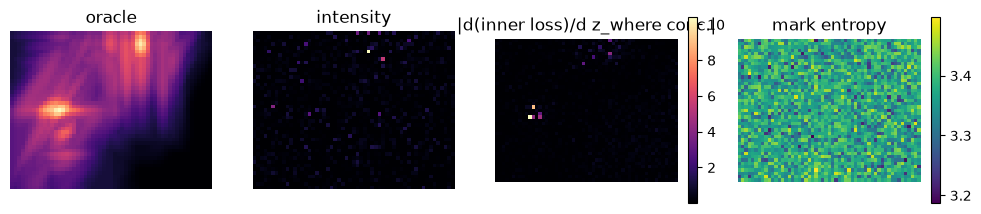

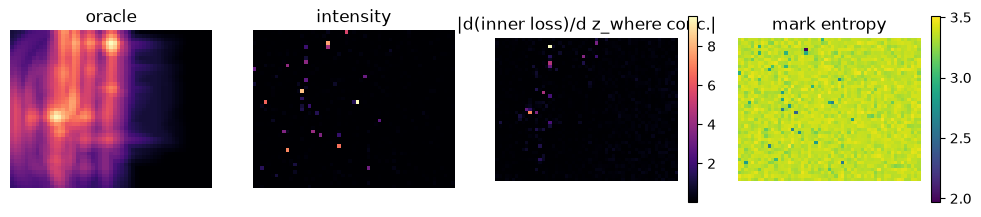

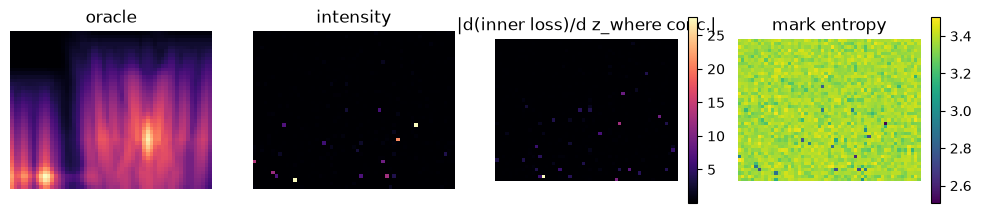

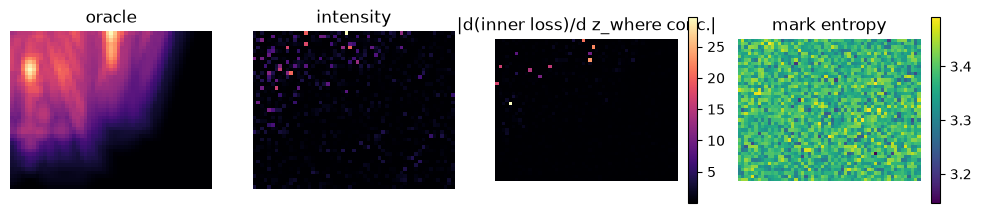

In [11]:
buffers = jax.lax.stop_gradient(dict(learner.parameters))

def inner_objective(params, key=0):
    return guide.tracer.loss(random.key(key), {**params, **buffers}, {},
                             learner.model, guide.guide, data)[0]

grads = jax.grad(inner_objective)(adapted)
where_grad = np.abs(np.asarray(grads["z_where_auto_concentration"]))
where_grad = where_grad.reshape(data.shape[0], *grid)

rate_mean = np.exp(np.asarray(adapted["z_rate_auto_concentration"])) / \
            np.exp(np.asarray(adapted["z_rate_auto_rate"]))
print("posterior E[z_rate] per image:", np.round(rate_mean, 3),
      f"(prior mean {placements.expected_count})")

rho = np.asarray(predictions["z_mark"]["value"]).mean(axis=0)  # (B, h, w, K)
mark_entropy = -np.asarray((rho * np.log(rho + 1e-12)).sum(axis=-1))
for i in range(data.shape[0]):
    peak = np.unravel_index(intensity[i].argmax(), intensity[i].shape)
    print(f"image {i}: peak anchor {peak} "
          f"glyph {int(rho[i][peak].argmax())} "
          f"(p={float(rho[i][peak].max()):.2f}, "
          f"entropy {float(mark_entropy[i][peak]):.2f} "
          f"of max {np.log(rho.shape[-1]):.2f})")

for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    axes[0].imshow(oracle[i], cmap="magma")
    axes[0].set_title("oracle")
    axes[1].imshow(intensity[i], cmap="magma")
    axes[1].set_title("intensity")
    im = axes[2].imshow(where_grad[i], cmap="magma")
    axes[2].set_title("|d(inner loss)/d z_where conc.|")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    im = axes[3].imshow(mark_entropy[i], cmap="viridis")
    axes[3].set_title("mark entropy")
    fig.colorbar(im, ax=axes[3], fraction=0.046)
    for ax in axes:
        ax.set_axis_off()

## How much inner budget does this batch need?

Outer metrics as a function of `max_steps`. Each point re-runs the full inner
solve eagerly, so this cell costs minutes locally -- it is meant for the pod,
where the per-evaluation cost is small.

In [ ]:
budgets = [5, 10, 25, 50, 100, 200]  # pod: extend to 100, 200, ...
rows = []
for budget in budgets:
    budget_guide = hydra.utils.instantiate(cfg.guide,
                                           max_steps=budget)(learner.model)
    metrics = outer_metrics(budget_guide)
    rows.append(metrics)
    print(f"max_steps {budget}: {metrics}", flush=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, key in zip(axes, ("loss", "nll", "kl")):
    ax.plot(budgets, [r[key] for r in rows], marker="o")
    ax.axhline(fresh[key], color="grey", linestyle="--", label="fresh guide")
    ax.set_xlabel("max_steps")
    ax.set_title(key)
    ax.legend()